# Standard problem 3

## Problem specification

This problem is to calculate a single domain limit of a cubic magnetic particle. This is the size $L$ of equal energy for the so-called flower state (which one may also call a splayed state or a modified single-domain state) on the one hand, and the vortex or curling state on the other hand.

Geometry:

A cube with edge length, $L$, expressed in units of the intrinsic length scale, $l_\text{ex} = \sqrt{A/K_\text{m}}$, where $K_\text{m}$ is a magnetostatic energy density, $K_\text{m} = \frac{1}{2}\mu_{0}M_\text{s}^{2}$.

Material parameters: 

- uniaxial anisotropy $K_\text{u}$ with $K_\text{u} = 0.1 K_\text{m}$, and with the easy axis directed parallel to a principal axis of the cube (0, 0, 1),
- exchange energy constant is $A = \frac{1}{2}\mu_{0}M_\text{s}^{2}l_\text{ex}^{2}$.

More details about the standard problem 3 can be found in Ref. 1.

## Simulation

Firstly, we import all necessary modules and configure pyvista for static rendering.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import time
from scipy import constants

import neuralmag as nm

pv.set_jupyter_backend("static")

SOLVER_LABELS = {
    "llg": "LLG relax",
    "bb": "BB steepest descent",
}

# Switch between the damped-LLG relaxer and the Barzilai-Borwein steepest descent driver.
SELECTED_METHOD = "bb"

2026-04-22 13:36:24 NeuralMag:INFO [NeuralMag] Version 0.9.4


The following two functions are used for initialising the system's magnetisation [1].

In [2]:
# Function for initiaising the flower state.
def m_init_flower(state):
    return nm.VectorFunction(state).fill((0.0, 0.0, 1))


# Function for initialising the vortex state.
def m_init_vortex(state):
    x, y, z = state.coordinates(spaces="nnn", numpy=True)
    m = np.stack([np.ones_like(x) * 1e-9, z, -y], axis=-1)
    norm = np.linalg.norm(m, axis=-1, keepdims=True)
    return nm.VectorFunction(state, tensor=state.tensor(m / norm))

The following function is used for convenience. It takes two required arguments and one optional argument:

- $L$ - the cube edge length in units of $l_\text{ex}$,
- the function for initialising the system's magnetization, and
- the minimisation method, which defaults to `SELECTED_METHOD`.

By default it returns the relaxed system object. If `return_meta=True`, it also returns runtime and iteration metadata so that the notebook can compare the damped-LLG relaxer with the Barzilai-Borwein steepest descent driver.

Please refer to other tutorials for more details on how to create system objects and drive them using specific drivers.

In [3]:
def minimise_system_energy(L, m_init, method=SELECTED_METHOD, return_meta=False):
    N = 10  # discretisation in one dimension
    Ms = 8e5  # saturation magnetization
    A = 13e-12  # exchange constant
    Km = constants.mu_0 * Ms**2 / 2.0  # effective anisotropy
    lex = (A / Km) ** 0.5  # exchange length
    dx = L * lex / N

    mesh = nm.Mesh((N, N, N), (dx, dx, dx), origin=(-L * lex / 2, -L * lex / 2, -L * lex / 2))
    state = nm.State(mesh)

    state.material.Ms = Ms
    state.material.A = A
    state.material.alpha = 0.5
    state.material.Ku = 0.1 * Km
    state.material.Ku_axis = [0, 0, 1]

    state.m = m_init(state)

    nm.ExchangeField().register(state, "exchange")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.DemagField().register(state, "demag")
    nm.TotalField("exchange", "demag", "aniso").register(state)

    t_start = time.perf_counter()
    if method == "llg":
        solver = nm.LLGSolver(state)
        solver.relax()
        meta = {"runtime_s": time.perf_counter() - t_start, "iterations": None}
    elif method == "bb":
        solver = nm.EnergyMinimizer(state, tol=1e3, max_iter=2000)
        solver.minimize()
        meta = {"runtime_s": time.perf_counter() - t_start, "iterations": solver.n_iter}
    else:
        raise ValueError(f"Unknown minimization method: {method}")

    if return_meta:
        return state, meta
    return state


def estimate_crossing(L_array, flower_energies, vortex_energies):
    delta_E = np.subtract(vortex_energies, flower_energies)
    sign_change_indices = np.where(np.diff(np.sign(delta_E)))[0]
    if len(sign_change_indices) == 0:
        return None, delta_E

    zero_crossings = []
    for index in sign_change_indices:
        x1, x2 = L_array[index], L_array[index + 1]
        y1, y2 = delta_E[index], delta_E[index + 1]
        zero_crossing = x1 - y1 * (x2 - x1) / (y2 - y1)
        zero_crossings.append(zero_crossing)

    return abs(zero_crossings[0]), delta_E


def compare_minimizers(L_array, methods=("llg", "bb")):
    comparison = {}
    for method in methods:
        vortex_energies, flower_energies = [], []
        runtimes = []
        iterations = []

        for L in L_array:
            vortex, vortex_meta = minimise_system_energy(L, m_init_vortex, method=method, return_meta=True)
            flower, flower_meta = minimise_system_energy(L, m_init_flower, method=method, return_meta=True)

            vortex_energies.append(float(np.asarray(nm.config.backend.to_numpy(vortex.E))))
            flower_energies.append(float(np.asarray(nm.config.backend.to_numpy(flower.E))))
            runtimes.append(vortex_meta["runtime_s"] + flower_meta["runtime_s"])

            if vortex_meta["iterations"] is not None:
                iterations.append(vortex_meta["iterations"] + flower_meta["iterations"])

        crossing, delta_E = estimate_crossing(L_array, flower_energies, vortex_energies)
        comparison[method] = {
            "vortex_energies": vortex_energies,
            "flower_energies": flower_energies,
            "delta_E": delta_E,
            "crossing": crossing,
            "total_runtime_s": float(np.sum(runtimes)),
            "avg_runtime_s": float(np.mean(runtimes)),
            "avg_iterations": float(np.mean(iterations)) if iterations else None,
        }

    return comparison


def compare_state_images(L, m_init, state_name, methods=("llg", "bb")):
    plotter = pv.Plotter(shape=(1, len(methods)))
    summaries = []

    for column, method in enumerate(methods):
        state, meta = minimise_system_energy(L, m_init, method=method, return_meta=True)
        filename = f"standard-problem-3/{state_name.lower()}-{method}-comparison.vti"
        state.write_vti(["m"], filename)

        mesh = pv.read(filename)
        glyphs = mesh.glyph(orient="m", scale="m", factor=1e-8)

        plotter.subplot(0, column)
        plotter.add_text(SOLVER_LABELS[method], font_size=12)
        plotter.add_mesh(glyphs, color="white", lighting=True, smooth_shading=True)
        plotter.view_isometric()

        summaries.append({
            "method": method,
            "energy": float(np.asarray(nm.config.backend.to_numpy(state.E))),
            "runtime_s": meta["runtime_s"],
            "iterations": meta["iterations"],
        })

    plotter.link_views()
    plotter.show()
    return summaries


def print_state_image_summary(state_name, summaries):
    print(f"{state_name} state comparison")
    for values in summaries:
        line = (
            f"- {SOLVER_LABELS[values['method']]}: E = {values['energy']:.6e} J, "
            f"runtime = {values['runtime_s']:.2f}s"
        )
        if values["iterations"] is not None:
            line += f", BB iterations = {values['iterations']}"
        print(line)


def plot_method_comparison(L_array, comparison):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for method, values in comparison.items():
        label = SOLVER_LABELS[method]
        axes[0].plot(L_array, values["flower_energies"], "o--", label=f"flower ({label})")
        axes[0].plot(L_array, values["vortex_energies"], "o-", label=f"vortex ({label})")

        crossing_label = label
        if values["crossing"] is not None:
            crossing_label += f", L*={values['crossing']:.3f}"
        axes[1].plot(L_array, values["delta_E"], "o-", label=crossing_label)

    axes[0].set_xlabel("L (lex)")
    axes[0].set_ylabel("E (J)")
    axes[0].set_title("Method comparison by state")
    axes[0].grid()
    axes[0].legend()

    axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle=":")
    axes[1].set_xlabel("L (lex)")
    axes[1].set_ylabel(r"$E_\mathrm{vortex} - E_\mathrm{flower}$ (J)")
    axes[1].set_title("Crossing comparison")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def print_method_summary(comparison):
    print("Method comparison for standard problem 3")
    for method, values in comparison.items():
        line = (
            f"- {SOLVER_LABELS[method]}: crossing ~= {values['crossing']:.3f}, "
            f"total runtime = {values['total_runtime_s']:.2f}s, "
            f"average runtime per L = {values['avg_runtime_s']:.2f}s"
        )
        if values["avg_iterations"] is not None:
            line += f", average BB iterations per L = {values['avg_iterations']:.1f}"
        print(line)

### Relaxed magnetization states

Each image pair below compares the damped-LLG relaxer and the Barzilai-Borwein steepest descent minimizer for the same initial state at $L=8$.

**Vortex** state:

2026-04-22 13:36:24.980 (   0.661s) [    F2FA632048E0]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
2026-04-22 13:36:25 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.54864e-09 x 4.54864e-09 x 4.54864e-09)
2026-04-22 13:36:25 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-22 13:36:26 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 13:36:26 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-22 13:36:34 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 13:36:34 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 13:36:34 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 13:36:34 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-0

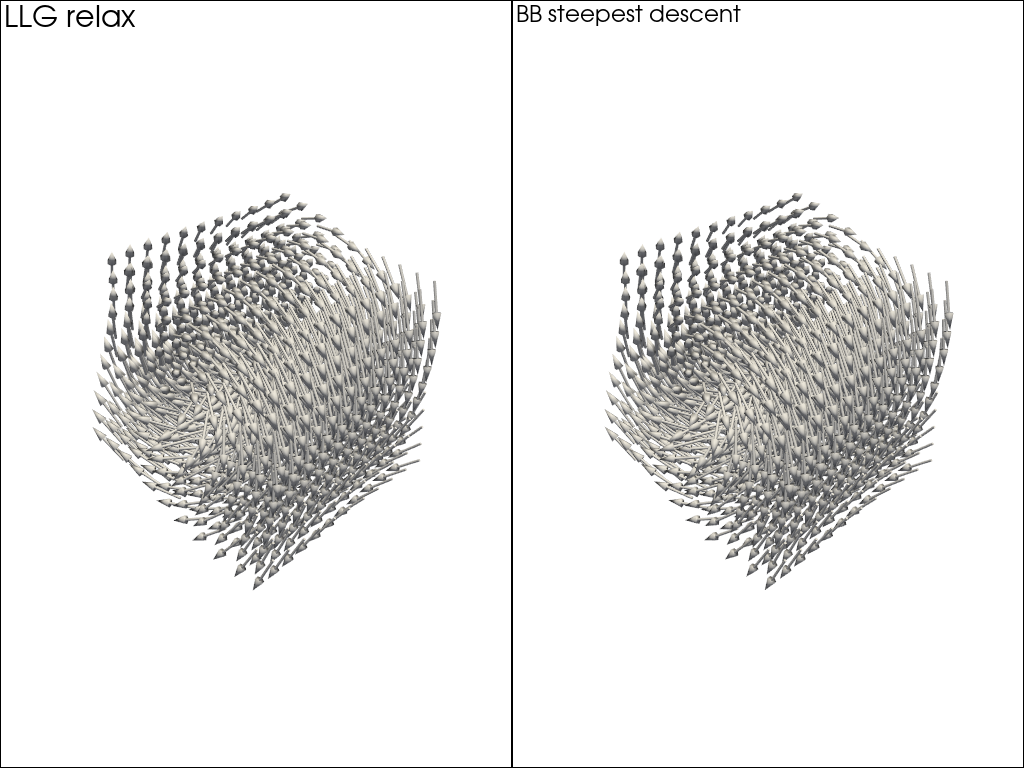

Vortex state comparison
- LLG relax: E = 8.320369e-18 J, runtime = 14.58s
- BB steepest descent: E = 8.320460e-18 J, runtime = 11.70s, BB iterations = 31


In [4]:
vortex_images = compare_state_images(8, m_init_vortex, "vortex")
print_state_image_summary("Vortex", vortex_images)

**Flower** state:

2026-04-22 13:37:06 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.54864e-09 x 4.54864e-09 x 4.54864e-09)
2026-04-22 13:37:06 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 13:37:06 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 13:37:06 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 13:37:06 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 13:37:06 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 13:37:06 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 13:37:08 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 13:37:08 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-22 13:37:

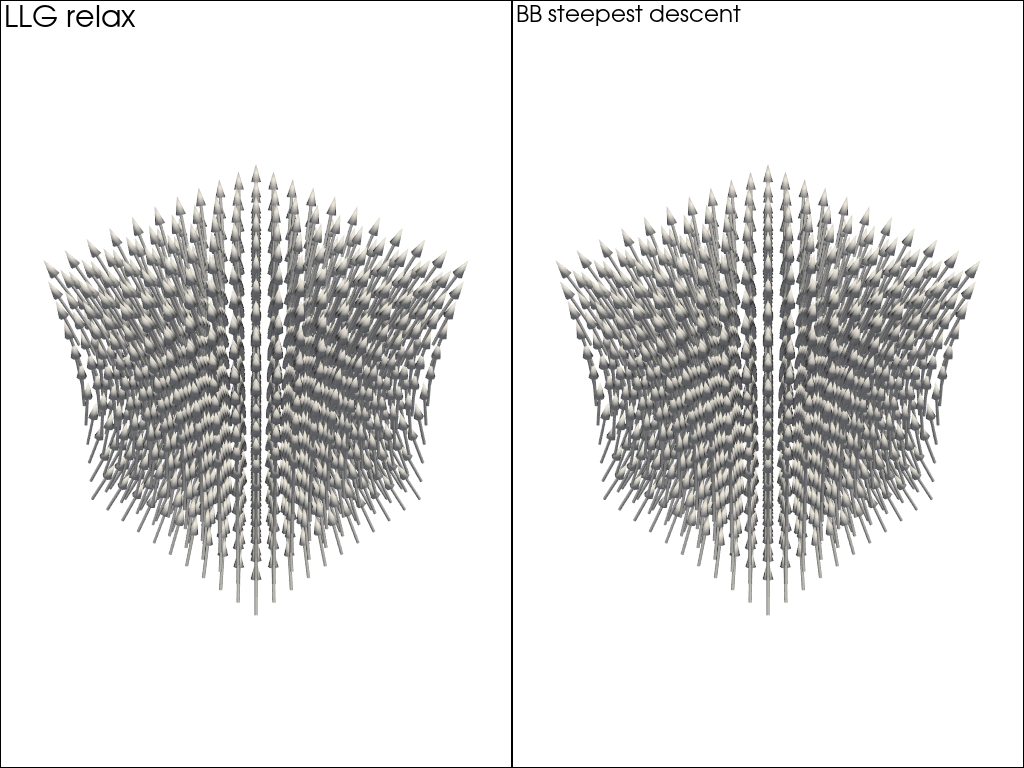

Flower state comparison
- LLG relax: E = 7.784920e-18 J, runtime = 13.21s
- BB steepest descent: E = 7.784938e-18 J, runtime = 11.34s, BB iterations = 12


In [5]:
flower_images = compare_state_images(8, m_init_flower, "flower")
print_state_image_summary("Flower", flower_images)

### Energy crossing

We can plot the energies of both vortex and flower states as a function of cube edge length $L$. The first plot below shows the selected method, while the second plot compares the damped-LLG relaxer and the Barzilai-Borwein steepest descent minimizer directly. The printed summary reports the crossing estimate, wall time, and BB iteration counts.

2026-04-22 13:37:35 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.71922e-09 x 4.71922e-09 x 4.71922e-09)
2026-04-22 13:37:35 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 13:37:35 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 13:37:35 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 13:37:35 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 13:37:35 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 13:37:35 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 13:37:36 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 13:37:36 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-22 13:37:

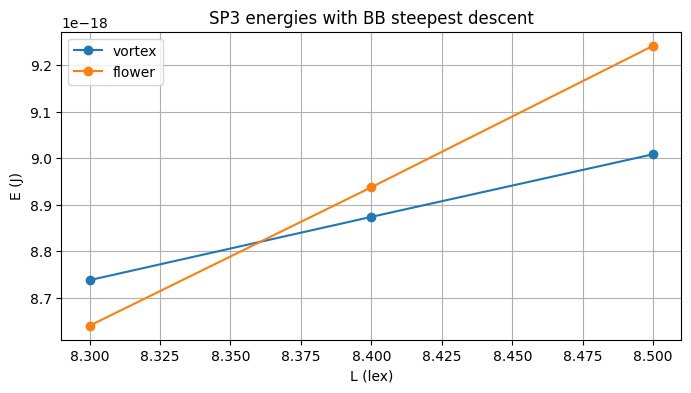

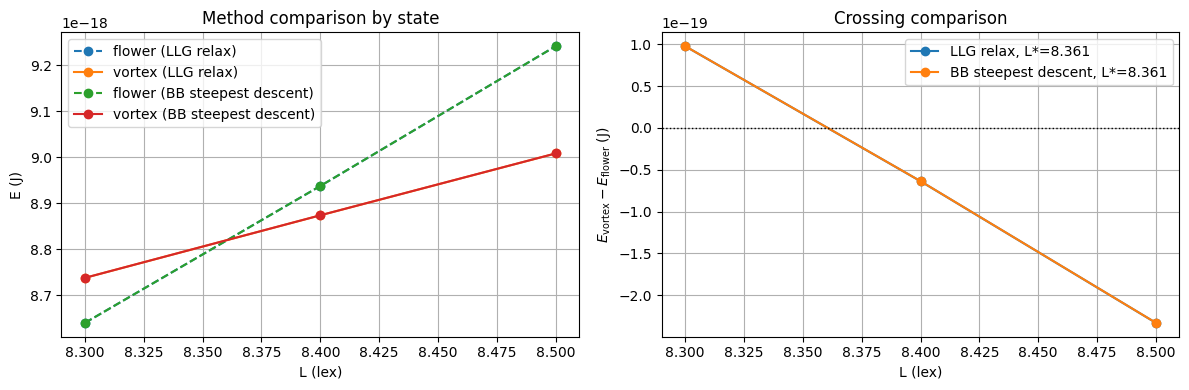

Method comparison for standard problem 3
- LLG relax: crossing ~= 8.361, total runtime = 79.96s, average runtime per L = 26.65s
- BB steepest descent: crossing ~= 8.361, total runtime = 69.27s, average runtime per L = 23.09s, average BB iterations per L = 40.7


In [6]:
L_array = [8.3, 8.4, 8.5]
comparison = compare_minimizers(L_array)

selected = comparison[SELECTED_METHOD]
plt.figure(figsize=(8, 4))
plt.plot(L_array, selected["vortex_energies"], "o-", label="vortex")
plt.plot(L_array, selected["flower_energies"], "o-", label="flower")
plt.xlabel("L (lex)")
plt.ylabel("E (J)")
plt.title(f"SP3 energies with {SOLVER_LABELS[SELECTED_METHOD]}")
plt.grid()
plt.legend()
plt.show()

plot_method_comparison(L_array, comparison)
print_method_summary(comparison)

Both methods should place the energy crossing in the same $8.3l_\text{ex}$ to $8.5l_\text{ex}$ interval. The comparison plot and printed summary let you check whether the BB minimizer reaches the same static energies with fewer iterations or lower wall time than the damped-LLG relaxer for this setup.

### Reduced energy landscape

The full micromagnetic energy landscape lives in a very high-dimensional space, so it cannot be visualized directly. What we can plot is a **2D slice** of that landscape around a chosen minimum.

In the helper below, the first axis points roughly from the chosen minimum toward the competing minimum, and the second axis is an orthogonal perturbation direction. The contour plot therefore shows a reduced energy landscape, and the overlaid BB path shows how the minimizer moves through that slice. If you set `surface=True`, the same slice is shown as a 3D surface with the energy encoded as height and color.

In [7]:
def build_sp3_state(L, m_init):
    N = 10  # discretisation in one dimension
    Ms = 8e5  # saturation magnetization
    A = 13e-12  # exchange constant
    Km = constants.mu_0 * Ms**2 / 2.0  # effective anisotropy
    lex = (A / Km) ** 0.5  # exchange length
    dx = L * lex / N

    mesh = nm.Mesh((N, N, N), (dx, dx, dx), origin=(-L * lex / 2, -L * lex / 2, -L * lex / 2))
    state = nm.State(mesh)

    state.material.Ms = Ms
    state.material.A = A
    state.material.alpha = 0.5
    state.material.Ku = 0.1 * Km
    state.material.Ku_axis = [0, 0, 1]

    state.m = m_init(state)

    nm.ExchangeField().register(state, "exchange")
    nm.UniaxialAnisotropyField().register(state, "aniso")
    nm.DemagField().register(state, "demag")
    nm.TotalField("exchange", "demag", "aniso").register(state)
    return state


def _scalar_as_float(value):
    return float(np.asarray(nm.config.backend.to_numpy(value)).reshape(()))


def _m_as_numpy(state):
    return np.asarray(nm.config.backend.to_numpy(state.m.tensor), dtype=float)


def _global_dot(lhs, rhs):
    return float(np.sum(lhs * rhs))


def _global_norm(value):
    return np.sqrt(max(_global_dot(value, value), 1e-30))


def _normalize_field(value):
    norms = np.linalg.norm(value, axis=-1, keepdims=True)
    return value / np.maximum(norms, 1e-14)


def _project_tangent(direction, reference):
    return direction - np.sum(direction * reference, axis=-1, keepdims=True) * reference


def _orthonormal_tangent_basis(reference, direction_1, direction_2):
    basis_1 = _project_tangent(direction_1, reference)
    basis_1 /= _global_norm(basis_1)

    basis_2 = _project_tangent(direction_2, reference)
    basis_2 -= _global_dot(basis_2, basis_1) * basis_1
    basis_2_norm = _global_norm(basis_2)
    if basis_2_norm < 1e-10:
        raise ValueError("The chosen energy-slice directions are nearly collinear.")
    basis_2 /= basis_2_norm
    return basis_1, basis_2


def _project_onto_basis(m, reference, basis_1, basis_2):
    delta = _project_tangent(m - reference, reference)
    return _global_dot(delta, basis_1), _global_dot(delta, basis_2)


def _evaluate_energy_slice(L, template_init, reference, basis_1, basis_2, a_values, b_values, batch_size=128):
    state = build_sp3_state(L, template_init)
    a_grid, b_grid = np.meshgrid(a_values, b_values)
    flat_a = a_grid.reshape(-1)
    flat_b = b_grid.reshape(-1)

    m_trials = reference[None, ...] + flat_a[:, None, None, None, None] * basis_1[None, ...]
    m_trials += flat_b[:, None, None, None, None] * basis_2[None, ...]
    m_trials = _normalize_field(m_trials)

    if getattr(nm.config.backend, "name", None) == "jax":
        import jax

        energy_fn = jax.jit(state.resolve(lambda m, E: E, ["m"]))
        batched_energy_fn = jax.jit(jax.vmap(energy_fn))
        flat_energies = []
        for start in range(0, m_trials.shape[0], batch_size):
            stop = start + batch_size
            flat_energies.append(np.asarray(batched_energy_fn(state.tensor(m_trials[start:stop]))))
        return np.concatenate(flat_energies).reshape(len(b_values), len(a_values))

    energies = np.empty((len(b_values), len(a_values)))
    for row, b_value in enumerate(b_values):
        for col, a_value in enumerate(a_values):
            m_trial = _normalize_field(reference + a_value * basis_1 + b_value * basis_2)
            state.m.tensor = state.tensor(m_trial)
            energies[row, col] = _scalar_as_float(state.E)
    return energies


def _record_bb_path(L, m_init, reference, basis_1, basis_2, max_iter=60, tol=1e3):
    state = build_sp3_state(L, m_init)
    minimizer = nm.EnergyMinimizer(state, tol=tol, max_iter=max_iter)

    path = [_project_onto_basis(_m_as_numpy(state), reference, basis_1, basis_2)]
    energies = [_scalar_as_float(state.E)]

    max_g = np.inf
    while minimizer.n_iter < max_iter and max_g > tol:
        max_g = _scalar_as_float(minimizer.step())
        path.append(_project_onto_basis(_m_as_numpy(state), reference, basis_1, basis_2))
        energies.append(_scalar_as_float(state.E))

    return np.asarray(path), np.asarray(energies)


def plot_energy_landscape(L=8.4, target="flower", method="bb", grid_size=21, max_iter=60, tol=1e3, surface=False, batch_size=128):
    init_map = {"flower": m_init_flower, "vortex": m_init_vortex}
    if target not in init_map:
        raise ValueError("target must be 'flower' or 'vortex'.")

    other_target = "vortex" if target == "flower" else "flower"
    target_init = init_map[target]
    other_init = init_map[other_target]

    reference_state, _ = minimise_system_energy(L, target_init, method=method, return_meta=True)
    other_state, _ = minimise_system_energy(L, other_init, method=method, return_meta=True)
    initial_state = build_sp3_state(L, target_init)

    reference_m = _m_as_numpy(reference_state)
    other_m = _m_as_numpy(other_state)
    initial_m = _m_as_numpy(initial_state)

    basis_1, basis_2 = _orthonormal_tangent_basis(
        reference_m,
        other_m - reference_m,
        initial_m - reference_m,
    )

    other_a, other_b = _project_onto_basis(other_m, reference_m, basis_1, basis_2)
    initial_a, initial_b = _project_onto_basis(initial_m, reference_m, basis_1, basis_2)

    a_extent = 1.25 * max(abs(other_a), abs(initial_a), 0.05)
    b_extent = 1.25 * max(abs(other_b), abs(initial_b), 0.05)
    a_values = np.linspace(-a_extent, a_extent, grid_size)
    b_values = np.linspace(-b_extent, b_extent, grid_size)
    a_grid, b_grid = np.meshgrid(a_values, b_values)

    energies = _evaluate_energy_slice(
        L,
        target_init,
        reference_m,
        basis_1,
        basis_2,
        a_values,
        b_values,
        batch_size=batch_size,
    )
    path, path_energies = _record_bb_path(
        L,
        target_init,
        reference_m,
        basis_1,
        basis_2,
        max_iter=max_iter,
        tol=tol,
    )

    reference_energy = _scalar_as_float(reference_state.E)
    delta_energies = energies - reference_energy
    delta_path_energies = path_energies - reference_energy

    if surface:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection="3d")
        surface_plot = ax.plot_surface(a_grid, b_grid, delta_energies, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
        ax.plot(path[:, 0], path[:, 1], delta_path_energies, color="white", marker="o", linewidth=1.5, markersize=3, label="BB path")
        ax.scatter([0.0], [0.0], [0.0], color="red", s=50, label=f"{target} minimum")
        ax.scatter([other_a], [other_b], [delta_energies[np.abs(b_values - other_b).argmin(), np.abs(a_values - other_a).argmin()]], color="cyan", s=40, label=f"{other_target} minimum")
        ax.set_xlabel(r"$c_1$")
        ax.set_ylabel(r"$c_2$")
        ax.set_zlabel(r"$E - E_\mathrm{min}$ (J)")
        ax.set_title(f"SP3 reduced energy surface around the {target} minimum")
        fig.colorbar(surface_plot, ax=ax, pad=0.1, shrink=0.7, label=r"$E - E_\mathrm{min}$ (J)")
        ax.legend()
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        filled = ax.contourf(a_grid, b_grid, delta_energies, levels=25, cmap="viridis")
        ax.contour(a_grid, b_grid, delta_energies, levels=25, colors="black", linewidths=0.5, alpha=0.35)
        ax.plot(path[:, 0], path[:, 1], color="white", marker="o", linewidth=1.5, markersize=3, label="BB path")
        ax.scatter([0.0], [0.0], color="red", s=60, label=f"{target} minimum")
        ax.scatter([other_a], [other_b], color="cyan", s=50, label=f"{other_target} minimum")
        ax.scatter([initial_a], [initial_b], color="orange", s=50, label=f"{target} initial state")
        ax.set_xlabel(r"$c_1$ (toward competing minimum)")
        ax.set_ylabel(r"$c_2$ (orthogonal perturbation)")
        ax.set_title(f"SP3 reduced energy landscape around the {target} minimum")
        fig.colorbar(filled, ax=ax, label=r"$E - E_\mathrm{min}$ (J)")
        ax.legend()
        plt.show()

    return {
        "a_grid": a_grid,
        "b_grid": b_grid,
        "delta_energies": delta_energies,
        "path": path,
        "delta_path_energies": delta_path_energies,
        "reference_energy": reference_energy,
        "target": target,
        "method": method,
    }


plot_energy_landscape_slice = plot_energy_landscape

2026-04-22 13:42:30 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 10 (size = 4.77607e-09 x 4.77607e-09 x 4.77607e-09)
2026-04-22 13:42:30 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-22 13:42:30 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-22 13:42:30 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-22 13:42:31 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')
2026-04-22 13:42:31 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-22 13:42:31 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-22 13:42:32 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-22 13:42:35 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energ

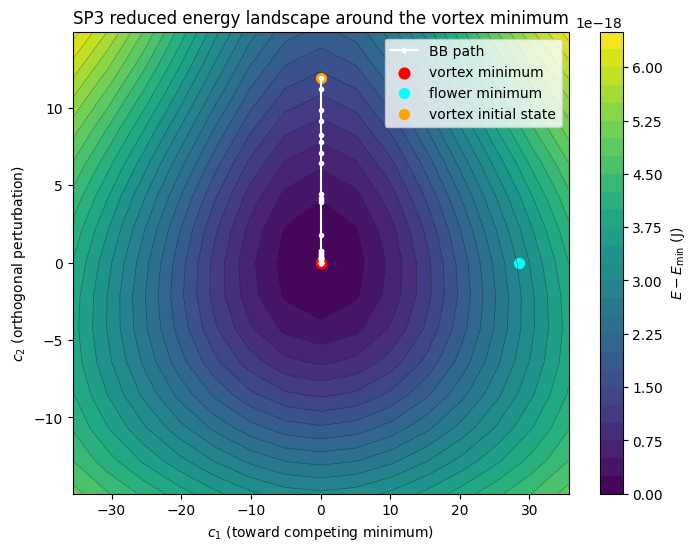

In [9]:
landscape_flower = plot_energy_landscape(
    L=8.4,
    target="vortex",
    method="bb",
    grid_size=15,
    max_iter=40,
    surface=False,
)

# Optional 3D view of the same reduced slice.
# landscape_flower_surface = plot_energy_landscape(
#     L=8.4,
#     target="flower",
#     method="bb",
#     grid_size=15,
#     max_iter=40,
#     surface=True,
# )

## References

[1] µMAG Site Directory http://www.ctcms.nist.gov/~rdm/mumag.org.

This tutorial was adapted from [Ubermag](https://ubermag.github.io/).